### Advanced Indexing

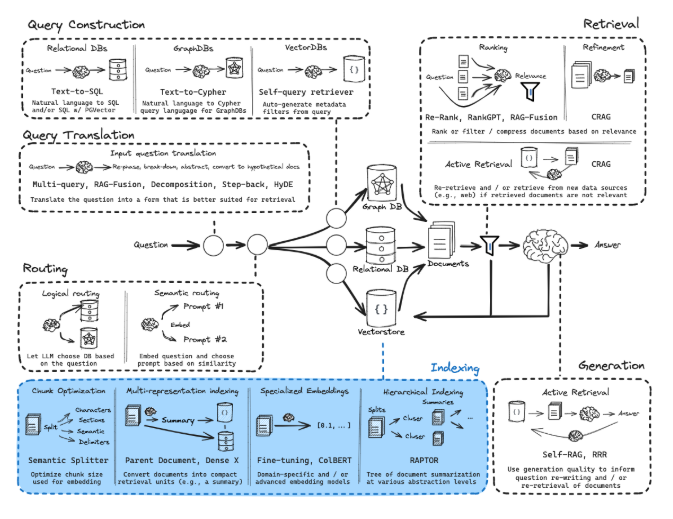

### Multi-Reporesentation indexing 

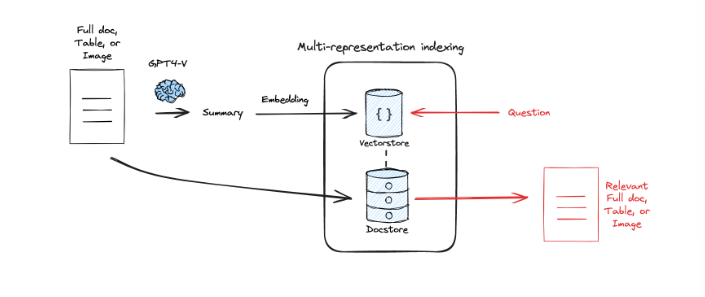

#### 一、核心动机：检索与生成的矛盾  
在标准的 RAG 流程中，我们通常将文档切成小块，既用它来做检索，也把它喂给模型做生成。但这里存在一个痛点：  

• 检索需要精准： 原始文本块可能包含很多噪音，不够精炼，导致语义搜索时匹配度不高  

• 生成需要上下文： 如果为了检索精准把块切得太小，模型在生成答案时就会丢失重要的背景信息  

多重表示索引通过一种“分身术”解决了这个问题：它为同一份资料准备了两个版本——一个专门负责被搜到，另一个专门负责提供答案

#### 二、工作原理
- 蒸馏与总结：利用LLM对原始文档进行处理，生成一个简要的摘要命令。摘要包含了文档的核心观点和关键词，专门为检索优化  
- 摘要索引：只对高度优化的摘要进行向量化，并存入向量存储
- 全文检索：将未经切割的原始完整文档存储在一个独立的文档存储中
- 关联检索：当用户提问时，系统去搜摘要。一旦命中某个摘要，它会通过一个唯一的 doc_id（文档 ID）关联到 Doc Store 中，并把完整的原始文档提取出来给 LLM 进行生成

#### 三、技术优势
适合超长上下文窗口的大模型。既然模型现在能一次性处理几十页甚至几百页的内容，我们就不必再担心文档太长，直接把整篇相关的文章丢给它，让它在完整的语境下回答问题，准确率会大幅提升

# 这一步开魔法

In [1]:
import os
import uuid
import warnings
from typing import List, Dict, Any

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.retrievers import BaseRetriever

from langchain_community.chat_models.tongyi import ChatTongyi
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# 忽略不安全请求警告（如果您决定继续使用 verify=False）
warnings.filterwarnings("ignore", message="Unverified HTTPS request")

WEB_URL1 = "https://lilianweng.github.io/posts/2023-06-23-agent/"
WEB_URL2 = "https://lilianweng.github.io/posts/2024-02-05-human-data-quality/"

# 设置 API Key（建议从环境变量读取）
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

# 模型配置
LLM_MODEL = "qwen-turbo"
TEMPERATURE = 0.0
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
EMBEDDING_MODEL = "all-MiniLM-L6-v2"

# 初始化通义千问模型
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)

# 自定义 requests 会话，添加重试和 headers
def create_session_with_retries(retries=3, backoff_factor=0.5, status_forcelist=(500, 502, 504)):
    session = requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=status_forcelist,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    })
    return session

# 加载文档
docs = []
urls = [WEB_URL1, WEB_URL2]

for url in urls:
    try:
        # 为每个 URL 创建带有重试和 headers 的加载器
        session = create_session_with_retries()
        loader = WebBaseLoader(url, requests_kwargs={'verify': False}, session=session)
        loaded_docs = loader.load()
        docs.extend(loaded_docs)
        print(f"成功加载 {url}")
    except Exception as e:
        print(f"加载 {url} 失败: {e}")

if docs:
    print(f"成功加载 {len(docs)} 个文档")
    print(docs[0])
else:
    print("未加载到任何文档")

c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


成功加载 https://lilianweng.github.io/posts/2023-06-23-agent/
成功加载 https://lilianweng.github.io/posts/2024-02-05-human-data-quality/
成功加载 2 个文档
page_content='





LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Agent System Overview

Component One: Planning

Task Decomposition

Self-Reflection


Component Two: Memory

Types of Memory

Maximum Inner Product Search (MIPS)


Component Three: Tool Use

Case Studies

Scientific Discovery Agent

Generative Agents Simulation

Proof-of-Concept Examples


Challenges

Citation

References





Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. Th

# 这一步关魔法

In [2]:

chain = (
  {"doc": lambda x: x.page_content}
  | ChatPromptTemplate.from_template("Summarize the follosing document: \n\n {doc}")
  | llm
  | StrOutputParser()
)

summaries = chain.batch(docs,{"max_concurrency" : 5})

# 这一步开魔法

In [3]:

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


# Vector Store（存 summary）
vectorstore = Chroma(
    collection_name="summaries",
    embedding_function=embedding,
)

doc_ids = [str(uuid.uuid4()) for _ in docs]

summary_docs = [
    Document(page_content=s, metadata={"parent_id": doc_ids[i]})
    for i, s in enumerate(summaries)
]

vectorstore.add_documents(summary_docs)

# parent 存到 dict 里
parent_store = {
    doc_ids[i]: docs[i]
    for i in range(len(docs))
}


class SummaryLinkingRetriever(BaseRetriever):
    retriever: Any
    parent_store: Dict[str, Document]

    def _get_relevant_documents(self, query: str) -> List[Document]:
        summary_hits = self.retriever.invoke(query)
        return [
            self.parent_store[hit.metadata["parent_id"]]
            for hit in summary_hits
        ]

retriever = SummaryLinkingRetriever(
    retriever=vectorstore.as_retriever(),
    parent_store=parent_store
)

C:\Users\23017\AppData\Local\Temp\ipykernel_31704\4192640885.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1060.35it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_31704\4192640885.py:7: LangChainDepre

In [4]:
query = " Memory in agents"
sub_docs = vectorstore.similarity_search(query, k =1)
print(sub_docs[0].page_content)

**Summary of "LLM Powered Autonomous Agents" by Lilian Weng**

This article explores the concept of **LLM-powered autonomous agents**, which leverage large language models (LLMs) as the central controller to perform complex tasks. These agents are designed to plan, remember, and use tools effectively, making them capable of solving a wide range of problems.

---

### **Key Components of LLM-Powered Autonomous Agents**

#### 1. **Planning**
- **Task Decomposition**: Breaking down complex tasks into smaller subgoals using techniques like Chain of Thought (CoT) and Tree of Thoughts (ToT). CoT involves step-by-step reasoning, while ToT explores multiple reasoning paths.
- **Self-Reflection**: Enhancing performance through iterative learning and correction of past actions. Techniques like ReAct (Reasoning and Acting) and Reflexion allow agents to reflect on their decisions and improve over time.

#### 2. **Memory**
- **Types of Memory**:
  - **Short-Term Memory**: Equivalent to in-context l

In [6]:
retrieved_docs = retriever.invoke(query,n_results=1)
print(retrieved_docs[0].page_content[0:500])







LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Agent System Overview

Component One: Planning

Task Decomposition

Self-Reflection


Component Two: Memory

Types of Memory

Maximum Inner Product Search (MIPS)


Component Three:
